# Hurricane-Matthew Label Model

This model utilizes satellite images from the Hurricane-Matthew disaster to label the damage present on a scale from 0 (undamaged) to 3 (severely damaged). We decided to use a Gradient Boosted Classifier to handle the fitting and predictions. It’s effective for tabular data, handles non-linear feature interactions, and provides feature importance, which helps interpret which metrics are most predictive. Gradient Boosting has several hyperparameters like`n_estimators`, `max_depth`, and `max_features`. These were tuned using cross-validation where we aimed for a high K1 score while also preventing overfitting.

Macro F1 was chosen because the dataset is very imbalanced. This score balances precision and recall for all classes, rather than favoring the majority classes (labels 1 and 3). We judged bias and variance from these K1 features. The model had a low bias because cross-validation scores generally tend to be consistent across each k fold. Overfitting was monitored by comparing per-fold training vs test performance and analyzing the summed confusion matrix. Feature importance is also revealed if the model relies too heavily on one feature.


In [9]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler
from skimage.morphology import disk
import cv2
from skimage import filters, color, feature
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

The features were image-based metrics. Sobel edge statistics, LBP (local binary patterns) statistics, entropy, and brown color.
- Sobel – captured edge intensity and structure
    - Mean provides a generalized measure of edge strength. A low mean suggests higher damage, as edges from structures like buildings are less distinct or missing.
    - Variance gives an idea of how different the edge intensity, where a high variance would indicate that some areas are more damaged than others (labels 1 & 2)
- LBP – captured texture patterns
     - Mean summarizes the overall texture uniformity. A low mean indicates that textures are disrupted, consistent with high damage.
- Entropy – measured information content in regions.
    - Mean represents the average uncertainty or randomness in the image. Low mean entropy suggests areas of uniformity (collapsed or flattened regions), while high mean entropy indicates complex, intact structures.
- Brown frequency – Brown is a common feature seen in flooded areas. 
    - A higher frequency indicates more flooded or damaged regions, while a lower frequency suggests less damage


> Note: Features were extracted and saved as Npy files for easy loading.


In [ ]:
#Load all relevant features in
sobel_edge = np.load("data/sobel_edge_hm.npy")
sobel_mean = np.load("data/sobel_mean_hm.npy")
sobel_var = np.load("data/sobel_var_hm.npy")
lbp_mean = np.load("data/lbp_mean_hm.npy")
lbp_median = np.load("data/lbp_median_hm.npy")
entropy_mean = np.load("data/entropy_mean_hm.npy")
brown = np.load('data/brown_hm.npy')

# labels of features for plotting
features = ['sobel_edge', 'sobel_var','sobel_mean', 'lbp_mean', 'entropy_mean','brown'] 
#X and Y arrays for splitting in training / test sets
X = np.concatenate([sobel_edge, sobel_var, sobel_mean, lbp_mean,  entropy_mean, brown], axis=1)
Y = np.load("data/hurricane-matthew_labels.npy")

> Note: Here is the function used to extract features. It is not used in this notebook.

In [7]:
def extract_features(images, save_path="data/", suffix="hm"):
    """
    Extracts features: sobel_edge, sobel_mean, lbp_median, lbp_mean, entropy_mean, brown, sobel_var
    and saves each as a separate .npy file in save_path.
    
    Parameters:
    - images: list or array of images (RGB)
    - save_path: folder to save .npy files
    - suffix: string to append at the end of each filename
    """
    import os
    os.makedirs(save_path, exist_ok=True)
    
    # Sobel features
    sobel_mean_list = []
    sobel_var_list = []
    sobel_edge_list = []
    
    for img in images:
        img_gray = color.rgb2gray(img)
        filtered = filters.sobel(img_gray)
        sobel_mean_list.append(np.mean(filtered))
        sobel_var_list.append(np.var(filtered))
        filtered_norm = filtered / filtered.max()
        sobel_edge_list.append(np.mean(filtered_norm > 0.4))
    
    np.save(save_path + f"sobel_mean_{suffix}.npy", np.array(sobel_mean_list).reshape(-1,1))
    np.save(save_path + f"sobel_var_{suffix}.npy", np.array(sobel_var_list).reshape(-1,1))
    np.save(save_path + f"sobel_edge_{suffix}.npy", np.array(sobel_edge_list).reshape(-1,1))
    
    # LBP features
    lbp_mean_list = []
    for img in images:
        img_gray = color.rgb2gray(img)
        lbp = feature.local_binary_pattern(img_gray, P=8, R=1, method="uniform")
        lbp_mean_list.append(np.mean(lbp))
    
    np.save(save_path + f"lbp_mean_{suffix}.npy", np.array(lbp_mean_list).reshape(-1,1))
    
    # Entropy feature
    entropy_mean_list = []
    for img in images:
        img_gray = color.rgb2gray(img)
        img_gray_uint = (img_gray * 255).astype(np.uint8)
        entropy_img = filters.rank.entropy(img_gray_uint, disk(3))
        entropy_mean_list.append(np.mean(entropy_img))
    
    np.save(save_path + f"entropy_mean_{suffix}.npy", np.array(entropy_mean_list).reshape(-1,1))
    
    # Brown fraction feature
    brown_list = []
    for img in images:
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        hue = hsv[:,:,0]
        sat = hsv[:,:,1]
        val = hsv[:,:,2]
        brown_mask = (hue >= 20) & (hue <= 40) & (sat >= 50) & (val <= 200)
        brown_fraction = brown_mask.sum() / brown_mask.size
        brown_list.append(brown_fraction)
    
    np.save(save_path + f"brown_{suffix}.npy", np.array(brown_list).reshape(-1,1))

To test the robustness of the code, we used Stratified K-Fold Cross-Validation. The dataset is split into `n = 4` folds, ensuring each fold preserves class distribution. The model is trained on the resampled training set and evaluated on the untouched test set. Fold-level metrics were averaged to give the overall performance of the model.

 For each fold, the model is trained on the training subset and evaluated on the test subset. We oversampled in the training fold using `RandomOverSampler` to reduce the class imbalance on label 2. The best results from oversampling occurred when `sampling_strategy={2: 10}`. 

In [ ]:
def stratified_CV(X, Y, model, n_split=5, metric=accuracy_score):
    '''
    Performs stratified k-fold cross-validation with oversampling on label 2, 
    returns metrics and predictions.

    X: feature matrix
    Y: target labels
    model: scikit-learn classifier that has fit/predict/predict_proba
    n_split: number of folds (default 5)
    metric: scoring function, default accuracy_score

    Returns:
    mean_score: average metric across folds
    values: list of metric values per fold
    sum_cm: confusion matrix summed over all folds
    Y_true: concatenated true labels from all folds
    Y_prob: concatenated predicted probabilities from all folds
    '''

    skf = StratifiedKFold(n_splits=n_split, shuffle=True, random_state=42)
    ros = RandomOverSampler(sampling_strategy={2: 10}, random_state=42) #oversampling for label 2 only

    values = []
    cms = []
    all_probs = []
    all_y_test = []

    for train_index, test_index in skf.split(X, Y): #run each train test on different splits of data
        print("Running Kfold...")
        X_train, X_test = X[train_index], X[test_index]
        Y_train, Y_test = Y[train_index], Y[test_index]

        X_train_rs, Y_train_rs = ros.fit_resample(X_train, Y_train)

        model.fit(X_train_rs, Y_train_rs)
        Y_pred = model.predict(X_test)
        

        #gather additional data for graphs and metrics
        values.append(metric(Y_test, Y_pred, average="macro"))
        cms.append(confusion_matrix(Y_test, Y_pred))

        Y_prob = model.predict_proba(X_test)
        all_probs.append(Y_prob)
        all_y_test.append(Y_test)
        
    Y_prob = np.concatenate(all_probs)
    Y_true = np.concatenate(all_y_test)
    sum_cm = np.sum(np.stack(cms), axis=0)

    return np.mean(values), values, sum_cm, Y_true, Y_prob

In [29]:
def run_model(X, Y, n):
    '''
    Trains a Gradient Boosting classifier with stratified cross-validation, 
    prints F1 scores, and saves evaluation plots.

    X: feature matrix
    Y: target labels
    n: number of cross-validation folds

    Saves the following files:
    - figures/hm_confusion_matrix.png : summed confusion matrix
    - figures/hm_KFold.png : per-fold F1 scores
    - figures/hm_importances.png : feature importances
    - figures/hm_ROC.png : ROC curves for all classes
    '''
    
    model = GradientBoostingClassifier(learning_rate=  0.1, max_depth =  5, n_estimators = 50)
    mean_score, values, matrix, Y_true, Y_prob = stratified_CV(X, Y, model, n_split= n, metric=f1_score)


    print(f"\nK1 Score = {mean_score}")
    print(f"K1 Values = {values}")

    
    '''
    Create Confusion Matrix
    '''
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=np.unique(Y))
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Hurricane Matthew Disaster Labels: Confusion Matrix for All Folds Summed")
    plt.tight_layout()
    plt.savefig("figures/hm_confusion_matrix.png", format="png")
    plt.close()


    '''
    Create Per-Fold F1 Scores Figure
    '''
    plt.plot(np.arange(1, n+1), values, marker='o')
    plt.xlabel("Fold")
    plt.ylabel("Macro F1 Score")
    plt.title("Hurricane Matthew Disaster Labels: Per-Fold F1 Scores")
    plt.ylim(0,1)
    plt.xticks(np.arange(1, n+1))
    plt.savefig("figures/hm_KFold.png", format="png")
    plt.close()


    '''
    Create Importances Figure
    '''
    importances = model.feature_importances_
    plt.figure(figsize=(10,6))
    plt.bar(range(len(importances)), importances)
    plt.xticks(range(len(importances)), features)
    plt.ylabel("Feature Importance")
    plt.xlabel("Feature Type")
    plt.title("Hurricane Matthew Disaster Labels: Gradient Boosted Tree Feature Importances")
    plt.savefig("figures/hm_importances.png", format="png")
    plt.close()

    '''
    Create ROC Curve
    '''
    classes = np.unique(Y_true)
    Y_bin = label_binarize(Y_true, classes=classes)

    plt.figure()
    for i, c in enumerate(classes):
        fpr, tpr, _ = roc_curve(Y_bin[:, i], Y_prob[:, i]) #compute false positive and true positive rates
        auc_c = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Label {c} (AUC={auc_c:.2f})")

    plt.plot([0,1],[0,1],"--") #diagonal line for random classifier
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.title("Hurricane Matthew Disaster Labels: ROC Curve per Disaster Label")
    plt.tight_layout()
    plt.savefig("figures/hm_ROC.png", format="png")
    plt.close()

The following code demonstrated model hyperparameter tuning done on the model using GridSearchCV:

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params (GB): {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}
Best CV Macro F1 (GB): 0.5036466520236832
Gradient Boosting - Validation Performance
Accuracy: 0.6
Macro F1: 0.37564102564102564
Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.17      0.20         6
           1       0.50      0.57      0.53        14
           2       0.00      0.00      0.00         1
           3       0.75      0.79      0.77        19

    accuracy                           0.60        40
   macro avg       0.38      0.38      0.38        40
weighted avg       0.57      0.60      0.58        40



/home/trelyk/miniconda3/envs/msse-python/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/trelyk/miniconda3/envs/msse-python/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/trelyk/miniconda3/envs/msse-python/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

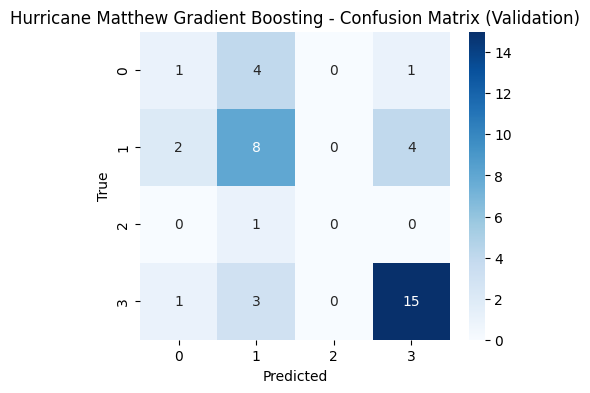

In [32]:
from sklearn.metrics import accuracy_score, classification_report, f1_score
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV

X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y,test_size=0.2, stratify=Y, random_state=42)
def evaluate_on_validation(name, model, X_valid, Y_valid):
    """
    Print accuracy, macro F1, classification report, and show confusion matrix for a trained model evaluated on the validation set.
    """
    valid_preds = model.predict(X_valid)

    acc = accuracy_score(Y_valid, valid_preds)
    f1 = f1_score(Y_valid, valid_preds, average="macro")

    print(f"{name} - Validation Performance")
    print("Accuracy:", acc)
    print("Macro F1:", f1)
    print("Classification Report:")
    print(classification_report(Y_valid, valid_preds))

    cm = confusion_matrix(Y_valid, valid_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Hurricane Matthew {name} - Confusion Matrix (Validation)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.savefig("figures/hm_GB_validation.png")

    return acc, f1

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gb = GradientBoostingClassifier(random_state=42)

gb_param_grid = {"n_estimators": [50, 100, 200],"learning_rate": [0.05, 0.1, 0.2],"max_depth": [2, 3, 5]} #options to cycle through 

gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, Y_train)

print("Best params (GB):", gb_grid.best_params_)
print("Best CV Macro F1 (GB):", gb_grid.best_score_)

best_gb = gb_grid.best_estimator_
gb_val_acc, gb_val_f1 = evaluate_on_validation(
    "Gradient Boosting",
    best_gb,
    X_valid,
    Y_valid
)

In [31]:
run_model(X,Y, 4)

Running Kfold...
Running Kfold...
Running Kfold...
Running Kfold...

K1 Score = 0.45839427635472463
K1 Values = [0.477328431372549, 0.37311126373626374, 0.4795256166982922, 0.5036117936117936]


![ROC](figures/hm_ROC.png)

![CM](figures/hm_confusion_matrix.png)

![KFOLD](figures/hm_KFold.png)



![Imp](figures/hm_importances.png)

As shown in the EDA, the difficulty in training this model had to do with the class discrepancies; mainly in labels 0 and 2. Given the low score of this model, it would be interesting to explore more features or include PCA dimensionality reduction on the features. We would also like to try a different Gradient Booster, like XGBoost, to see if the results differ much.